# Problem Statement



<html> <font color = Darkblue>
The purpose is to predict whether the Pima Indian women shows signs of diabetes or not. We are using a dataset collected by "National Institute of Diabetes and Digestive and Kidney Diseases" which consists of a number of attributes which would help us to perform this prediction.
</font>
</html>

<html>
<font color = blue>
<b>Constraints on data collection </b>

</font>
</html>

<html> <font color = Darkblue>
All patients whose data has been collected are females at least 21 years old of Pima Indian heritage
</font>
</html>

In [148]:
#Import all the necessary modules
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [149]:
# calculate accuracy measures and confusion matrix
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc

In [150]:
# importing ploting libraries
import matplotlib.pyplot as plt   
#importing seaborn for statistical plots
import seaborn as sns
# To enable plotting graphs in Jupyter notebook
%matplotlib inline 

# Q1. Load the PIMA Indian Diabetes file into Python DataFrame. 


The file can be accessed directly from the URL (https://archive.ics.uci.edu/ml/machine-learning-databases/pima-indians-diabetes/pima-indians-diabetes.data or you may first download it to a local folder and then load it into Python dataframe.  Let us assume the data frame is named pima_df


In [151]:
# Since it is a data file with no header, we will supply the column names which have been obtained from the above URL 
# Create a python list of column names called "names"
colnames = ['preg', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

#Load the file from local directory using pd.read_csv which is a special form of read_table
#while reading the data, supply the "colnames" list
pima_df = pd.read_csv("pima-indians-diabetes.data", names= colnames)

It is always a good practice to eye-ball raw data to get a feel of the data in terms of number of structure of the file, number of attributes, types of attributes and a general idea of likely challenges in the dataset. You would notice that it is a comma separated file. There are no column names!. Check the associated folders and find out about each attribute the name. What information is available about the data.

# Q2. Print 10 samples from the dataset

In [152]:
print(pima_df.head(10))

   preg  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0     6      148             72             35        0  33.6   
1     1       85             66             29        0  26.6   
2     8      183             64              0        0  23.3   
3     1       89             66             23       94  28.1   
4     0      137             40             35      168  43.1   
5     5      116             74              0        0  25.6   
6     3       78             50             32       88  31.0   
7    10      115              0              0        0  35.3   
8     2      197             70             45      543  30.5   
9     8      125             96              0        0   0.0   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
5                   

# Q3 Print the datatypes of each column and the shape of the dataset 

In [153]:
#Printing the DataTypes  of each column 
print(pima_df.dtypes)

#Printing the DataTypes  of each column 
print("Shape of the Dataset :" ,pima_df.shape)

preg                          int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object
Shape of the Dataset : (768, 9)


There are '0's in the data. Are they really valid '0's or they are missing values?
Plasma, BP, skin thickness etc. these values cannot be 0.
look at column by column logically to understand this.


# Q4 Replace all the 0s in the column with the median of the same column value accordingly.

In [154]:
pima_df['preg']= pima_df['preg'].replace(0,pima_df['preg'].median())
pima_df['Glucose']= pima_df['Glucose'].replace(0,pima_df['Glucose'].median())
pima_df['BloodPressure']= pima_df['BloodPressure'].replace(0,pima_df['BloodPressure'].median())
pima_df['SkinThickness']= pima_df['SkinThickness'].replace(0,pima_df['SkinThickness'].median())
pima_df['Insulin']= pima_df['Insulin'].replace(0,pima_df['Insulin'].median())
pima_df['BMI']= pima_df['BMI'].replace(0,pima_df['BMI'].median())
pima_df['DiabetesPedigreeFunction']= pima_df['DiabetesPedigreeFunction'].replace(0,pima_df['DiabetesPedigreeFunction'].median(axis = 0))
pima_df['Age']= pima_df['Age'].replace(0,pima_df['Age'].median())

print(pima_df.head(10))

   preg  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0     6      148             72             35     30.5  33.6   
1     1       85             66             29     30.5  26.6   
2     8      183             64             23     30.5  23.3   
3     1       89             66             23     94.0  28.1   
4     3      137             40             35    168.0  43.1   
5     5      116             74             23     30.5  25.6   
6     3       78             50             32     88.0  31.0   
7    10      115             72             23     30.5  35.3   
8     2      197             70             45    543.0  30.5   
9     8      125             96             23     30.5  32.0   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
5                   

# Q5 Print the descriptive statistics of each & every column using describe() function

In [155]:
#Lets analysze the distribution of the various attributes
pima_df.describe()

,preg,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,4.278646,121.656250,72.386719,27.334635,94.652344,32.450911,0.471876,33.240885,0.348958
std,3.021516,30.438286,12.096642,9.229014,105.547598,6.875366,0.331329,11.760232,0.476951
min,1.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,2.000000,99.750000,64.000000,23.000000,30.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,31.250000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# Q6 See the distribution of 'Class' variable and plot it using appropriate graph.

(array([500.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 268.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <a list of 10 Patch objects>)

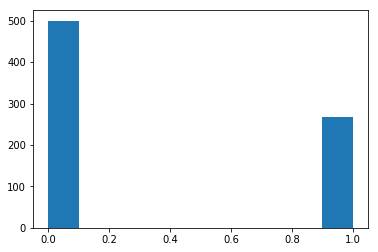

In [156]:
plt.hist(pima_df['Outcome'])

#Just for your understanding - Using univariate analysis check the individual attributes for their basic statistic such as central values, spread, tails etc. What are your observations (any two attributes). Its an optional step and will not be graded.

# Q7. Use pairplots and correlation method to observe the relationship between different variables and state your insights.
Hint: Use seaborn plot and check the relationship between different variables 


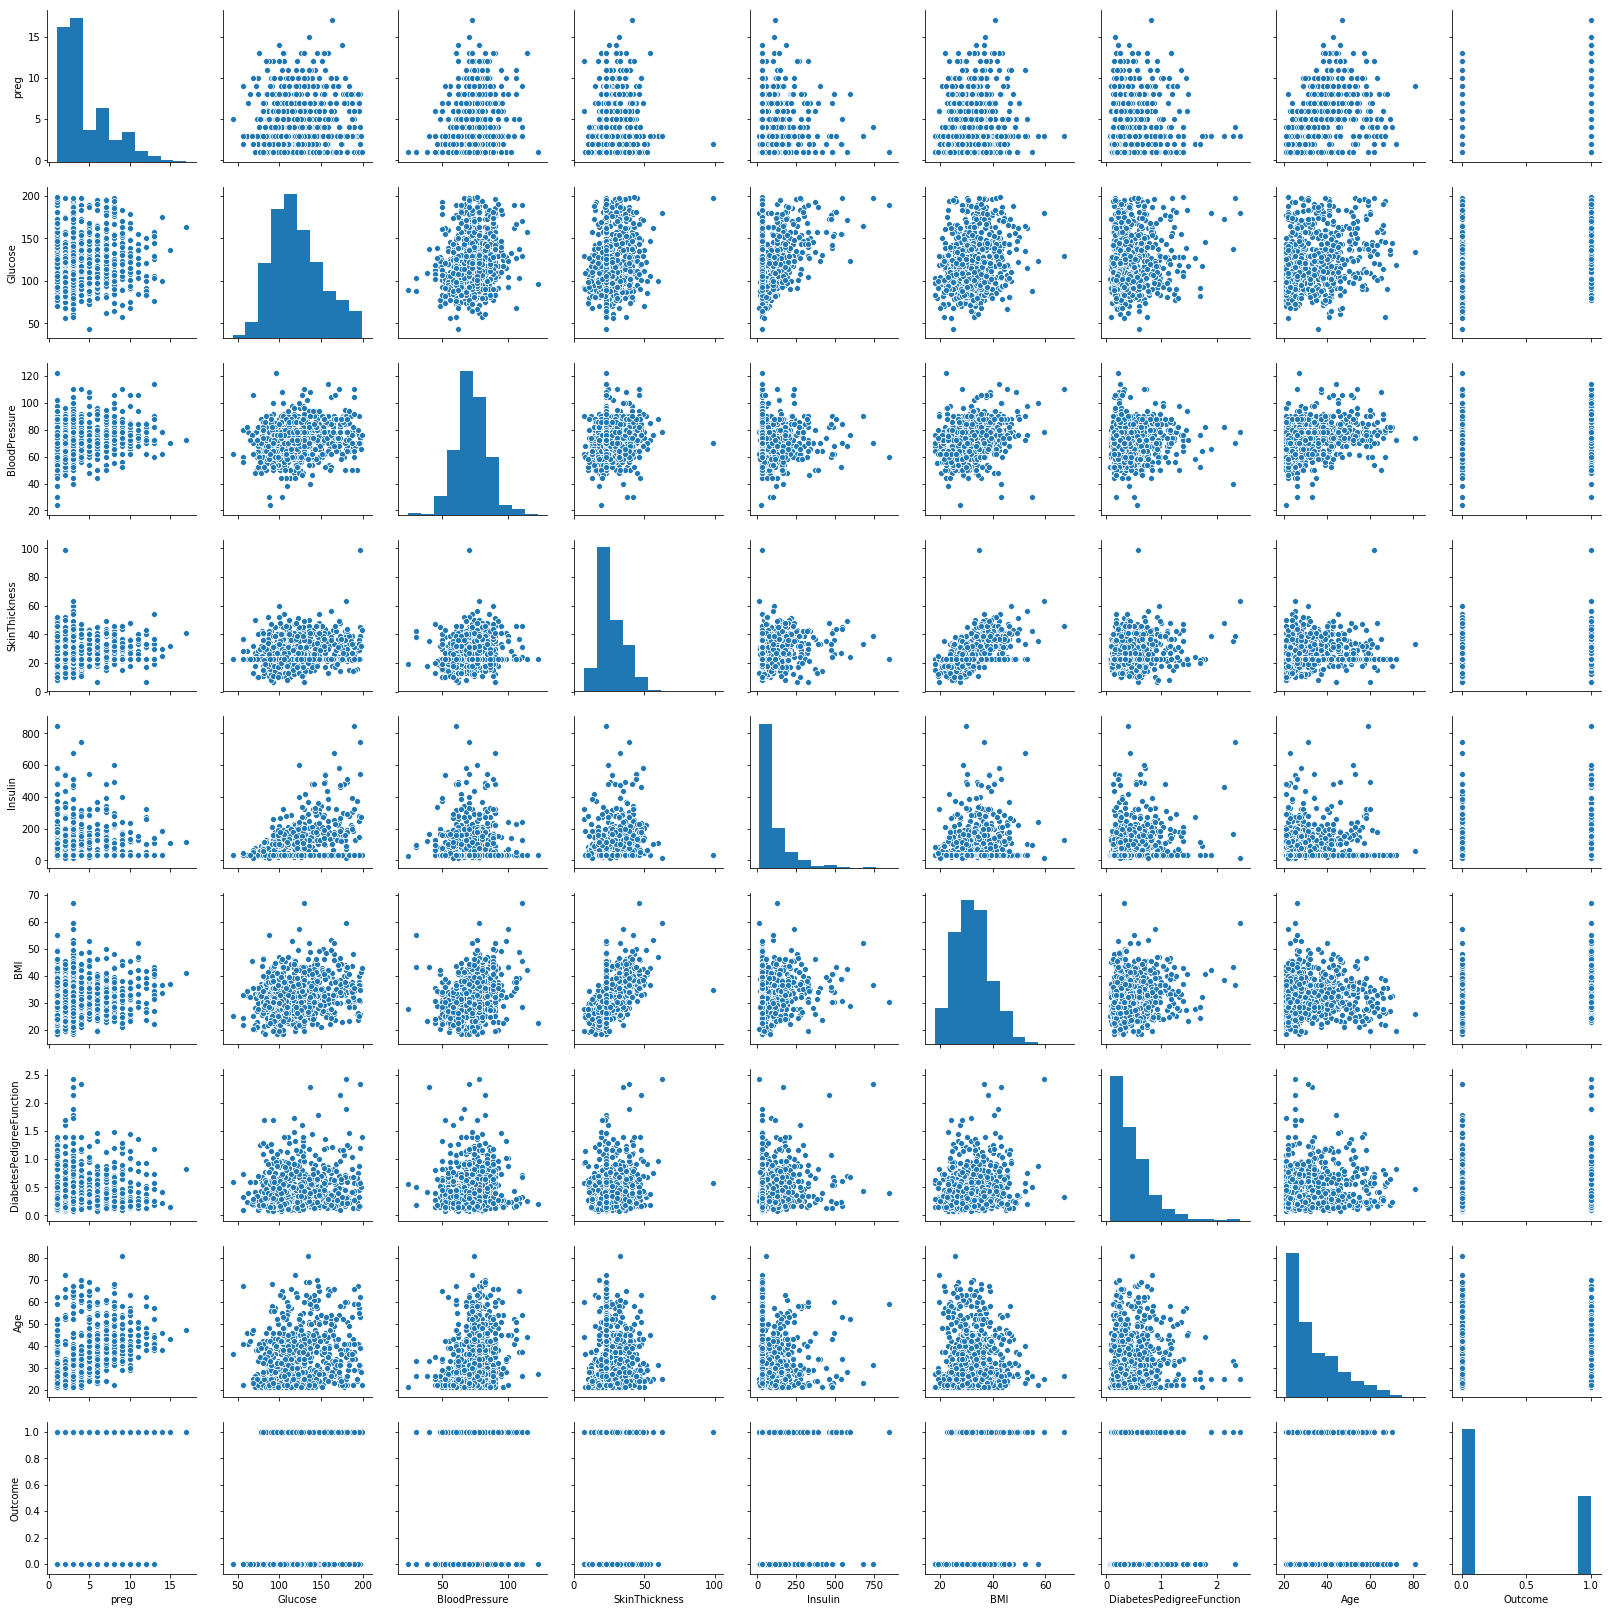

In [157]:
# Pairplot using sns
sns.pairplot(pima_df)
#from the data we infer that gulcose and BMI  plays an important role in deciding the outcome (strong relation)
# glucose with BP data is normally distributed  (positive relation , increase in 1 leads to increase in other )
# BMI and glucose  data is normally distributed (positive relation, increase in 1 leads to increase in other )

Using the plot - infer the relationship between different variables

# Q8 Split the pima_df into training and test set in the ratio of 70:30 (Training:Test).</b>


In [158]:
#Form the X and y variables 
X = pima_df.drop("Outcome", axis=1)
y = pima_df["Outcome"]



#Form the Training and Test data
test_size = 0.30 # taking 70:30 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

# Q9 Create the decision tree model using “entropy” method of reducing the entropy and fit it to training data.</b>



In [159]:
from sklearn.tree import DecisionTreeClassifier

#taking the default depth
model1=DecisionTreeClassifier(criterion='entropy',random_state=0)  
model1.fit(X_train,y_train)

#taking the max depth as squareroot of 768
model2=DecisionTreeClassifier(max_depth=29,criterion='entropy',random_state=0)  
model2.fit(X_train,y_train)

#Prediciting the model
ypred1 = model1.predict(X_test)
ypred2 = model2.predict(X_test)

# Q10 Print the accuracy of the model & print the confusion matrix 

In [160]:
acc1=metrics.accuracy_score(y_test,ypred1)
print("Accuracy of DT  using default depth :",acc1)


acc2=metrics.accuracy_score(y_test,ypred2)
print("Accuracy of DT using 29 depth :", acc2)

Accuracy of DT  using default depth : 0.7272727272727273
Accuracy of DT using 29 depth : 0.7272727272727273


Print the feature importance of the decision model - Optional

In [ ]:
# using the above model we get 74.8% accuracy  in deciding whether the patient is diabetic or not 
#i.e 74.8% of test data and predicited data are the same 

# Q12 Apply the Random forest model and print the accuracy of Random forest Model

In [161]:
from sklearn.ensemble import RandomForestClassifier
Rf_model = RandomForestClassifier(n_estimators=51,criterion='entropy',random_state=0 ) #provide odd estimators
Rf_model.fit(X_train,y_train)
#Prediciting the model
ypredRf = Rf_model.predict(X_test)

In [162]:
acc1=metrics.accuracy_score(y_test,ypredRf)
print("Accuracy using Random Forest :",acc1)

Accuracy using Random Forest : 0.7532467532467533


# Q13 Apply Adaboost Ensemble Algorithm for the same data and print the accuracy.

In [163]:
from sklearn.ensemble import AdaBoostClassifier
#taking the default clasiffier 
adaboost_model = AdaBoostClassifier(n_estimators=50,learning_rate=1,random_state=2)
adaboost_model.fit(X_train, y_train)
#Predict the response for test dataset
y_pred_ada = adaboost_model.predict(X_test)
print("Accuracy using ADA boost:",metrics.accuracy_score(y_test, y_pred_ada))

Accuracy using ADA boost: 0.7272727272727273


# Q14 - Apply Bagging Classifier Algorithm and print the accuracy.

In [164]:
from sklearn.ensemble import BaggingClassifier
#taking LR as base since most data is numeric
base_LR=LogisticRegression(random_state=2)
bag_LR = BaggingClassifier(base_estimator=base_LR,n_estimators=15,random_state=2)
bag_LR.fit(X_train, y_train)
#Predict the response for test dataset
y_pred_bag_LR = bag_LR.predict(X_test)
print("Accuracy using bagging classifier with baseLR:",metrics.accuracy_score(y_test, y_pred_bag_LR))

Accuracy using bagging classifier with baseLR: 0.7748917748917749


C:\Users\sush\Anaconda3\lib\site-packages\sklearn\linear_model\logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)
C:\Users\sush\Anaconda3\lib\site-packages\sklearn\linear_model\logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)
C:\Users\sush\Anaconda3\lib\site-packages\sklearn\linear_model\logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)
C:\Users\sush\Anaconda3\lib\site-packages\sklearn\linear_model\logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)
C:\Users\sush\Anaconda3\lib\site-packages\sklearn\linear_model\logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this w

# Q15 - Apply GradientBoost Classifier Algorithm for the same data and print the accuracy

In [165]:
from sklearn.ensemble import GradientBoostingRegressor
gboost=GradientBoostingRegressor(random_state=0)
gboost.fit(X_train, y_train)
#Predict the response for test dataset
y_pred_gboost = gboost.predict(X_test)
print("Accuracy using GradientBoostingRegressor :",metrics.accuracy_score(y_test, y_pred_gboost.round()))

Accuracy using GradientBoostingRegressor : 0.7792207792207793


# Next steps are optional and will not be graded.

Voting is one of the simplest ways of combining the predictions from multiple machine learning algorithms.

It works by first creating two or more standalone models from your training dataset. A Voting Classifier can then be used to wrap your models and average the predictions of the sub-models when asked to make predictions for new data.

Apply Voting Classfier on the given dataset and state your insights.

In [166]:
from sklearn.ensemble import VotingClassifier
boost_LR = AdaBoostClassifier(base_estimator=base_LR,n_estimators=50,random_state=2)
base_rf=RandomForestClassifier(n_estimators=101,random_state=2)
boost_dt = AdaBoostClassifier(n_estimators=50,random_state=2)
stacked = VotingClassifier(estimators = [('Boosted_LR',boost_LR),('RF', base_rf), ('Boosted_DT', boost_dt)],voting='soft')
stacked.fit(X_train, y_train)
y_pred_stack = stacked.predict(X_test)
print("Accuracy using voting stacked :",metrics.accuracy_score(y_test, y_pred_stack))

C:\Users\sush\Anaconda3\lib\site-packages\sklearn\linear_model\logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)
C:\Users\sush\Anaconda3\lib\site-packages\sklearn\linear_model\logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)
C:\Users\sush\Anaconda3\lib\site-packages\sklearn\linear_model\logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)
C:\Users\sush\Anaconda3\lib\site-packages\sklearn\linear_model\logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)
C:\Users\sush\Anaconda3\lib\site-packages\sklearn\linear_model\logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this w

Accuracy using voting stacked : 0.7922077922077922
